# 6. Electricity Load Forecasting (h+1) - Modeling: Ridge / XGBoost / LightGBM

This notebook strictly follows the logic defined in src/modeling/ and allows to:

- Understand each file in the modeling folder
- Explore the data and splits before training
- Compare Ridge, XGBoost, and LightGBM on the validation set (2024)
- Analyze errors and feature importance
- Evaluate the best model on the test set (2025)
- Save the final model

```
src/modeling/
├── config.py    ← features, dynamic splits, hyperparameters
├── models.py    ← model definitions (Ridge, XGBoost, LightGBM)
├── evaluate.py  ← MAE / RMSE computation
├── storage.py   ← parquet loading, temporal split, saving
└── train.py     ← orchestrator (calls the 4 modules above)
```

## 0. Setup

In [38]:
import sys
from pathlib import Path

# Add the project root and src/modeling directories to the Python path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "modeling"))

print(f"Project root : {PROJECT_ROOT}")

Project root : /Users/bachirijihane/energy-intelligence-platform


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [40]:
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3

In [41]:
# Check that the featured data is available
FEATURED_PATH = PROJECT_ROOT / "data" / "featured" / "country=FR"
years_available = sorted([int(p.name.split("=")[1]) for p in FEATURED_PATH.glob("year=*")])

print(f"Years available in data/featured/ : {years_available}")
assert len(years_available) > 0, "No featured files found — please run the features step first."

Years available in data/featured/ : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Configuration - config.py

`config.py` is the single source for:

* **`FEATURE_COLS`**: the input features used by the model
* **`TARGET_COL`**: the target variable to predict
* **Temporal splits**: dynamically computed based on the current year
* **Hyperparameters**: centralized here to avoid duplication between the notebook and `models.py`

In [42]:
# Import configuration variables
from src.modeling.config import (
    FEATURE_COLS, TARGET_COL,
    TRAIN_END, VAL_END, TEST_END,
    YEARS, COUNTRY,
    RIDGE_PARAMS, XGBOOST_PARAMS, LIGHTGBM_PARAMS,
)

print("=" * 50)
print(f"  Country       : {COUNTRY}")
print(f"  Years         : {YEARS[0]} → {YEARS[-1]}")
print()
print(f"  Train until   : {TRAIN_END.date()}")
print(f"  Val until     : {VAL_END.date()}")
print(f"  Test until    : {TEST_END.date()}")
print()
print(f"  Target        : {TARGET_COL}")
print(f"  Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"    - {f}")
print("=" * 50)


  Country       : FR
  Years         : 2015 → 2025

  Train until   : 2023-12-31
  Val until     : 2024-12-31
  Test until    : 2025-12-31

  Target        : target_load_t+1
  Features (10):
    - load_t
    - load_t-1
    - load_t-24
    - load_t-168
    - temperature_t
    - temperature_t-24
    - hour
    - is_weekday
    - day_of_week
    - week_of_year


In [43]:
# Models hyperparameters
print("Ridge params  :\n", RIDGE_PARAMS)
print("XGBoost params:\n", XGBOOST_PARAMS)
print("LightGBM params:\n", LIGHTGBM_PARAMS)

Ridge params  :
 {'alpha': 0.01}
XGBoost params:
 {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
LightGBM params:
 {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


## 2. Load data

`storage.load_features()` reads the parquet files from `data/featured/` and concatenates them into a single DataFrame sorted by datetime.

In [44]:
# Load the featured data
from src.modeling.storage import load_features

df = load_features(country=COUNTRY, years=YEARS)

[DATA] Loaded 96,262 rows | 2015-01-08 00:00:00+00:00 → 2025-12-31 22:00:00+00:00


In [45]:
print(f"Shape    : {df.shape}")
print(f"Index    : {df.index.min()}  →  {df.index.max()}")
print(f"Timezone : {df.index.tz}")
print()
df.head(3)

Shape    : (96262, 11)
Index    : 2015-01-08 00:00:00+00:00  →  2025-12-31 22:00:00+00:00
Timezone : UTC



,load_t,load_t-1,load_t-24,load_t-168,temperature_t,temperature_t-24,hour,is_weekday,day_of_week,week_of_year,target_load_t+1
datetime,,,,,,,,,,,
2015-01-08 00:00:00+00:00,65948.0,68372.0,67621.0,70929.0,5.154,4.354,0,1,3,2,64676.0
2015-01-08 01:00:00+00:00,64676.0,65948.0,66393.0,69773.0,5.704,3.204,1,1,3,2,61551.0
2015-01-08 02:00:00+00:00,61551.0,64676.0,63640.0,66417.0,6.354,2.254,2,1,3,2,60541.0


In [46]:
# Types and missing values check
info = pd.DataFrame({
    "dtype":    df.dtypes,
    "n_null":   df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
})
print(info)
assert info["n_null"].sum() == 0, "NaN are present — verify the features step."

                    dtype  n_null  pct_null
load_t            float64       0       0.0
load_t-1          float64       0       0.0
load_t-24         float64       0       0.0
load_t-168        float64       0       0.0
temperature_t     float32       0       0.0
temperature_t-24  float32       0       0.0
hour                int32       0       0.0
is_weekday          int64       0       0.0
day_of_week         int32       0       0.0
week_of_year        int64       0       0.0
target_load_t+1   float64       0       0.0


In [47]:
# Descriptive statistics of the features
df[FEATURE_COLS].describe().round(1)

,load_t,load_t-1,load_t-24,load_t-168,temperature_t,temperature_t-24,hour,is_weekday,day_of_week,week_of_year
count,96262.0,96262.0,96262.0,96262.0,96262.0,96262.0,96262.0,96262.0,96262.0,96262.0
mean,52365.7,52365.9,52372.8,52397.6,12.4,12.4,11.5,0.7,3.0,26.6
std,11443.2,11443.3,11447.9,11464.7,7.1,7.1,6.9,0.5,2.0,15.0
min,28744.0,28744.0,28744.0,28744.0,-10.1,-10.1,0.0,0.0,0.0,1.0
25%,43704.2,43704.2,43704.2,43704.2,7.3,7.3,5.2,0.0,1.0,14.0
50%,50616.5,50617.0,50622.0,50645.0,11.9,11.9,11.0,1.0,3.0,27.0
75%,60099.8,60100.0,60110.0,60163.2,17.3,17.3,17.0,1.0,5.0,40.0
max,94492.0,94492.0,94492.0,94492.0,40.7,40.7,23.0,1.0,6.0,52.0


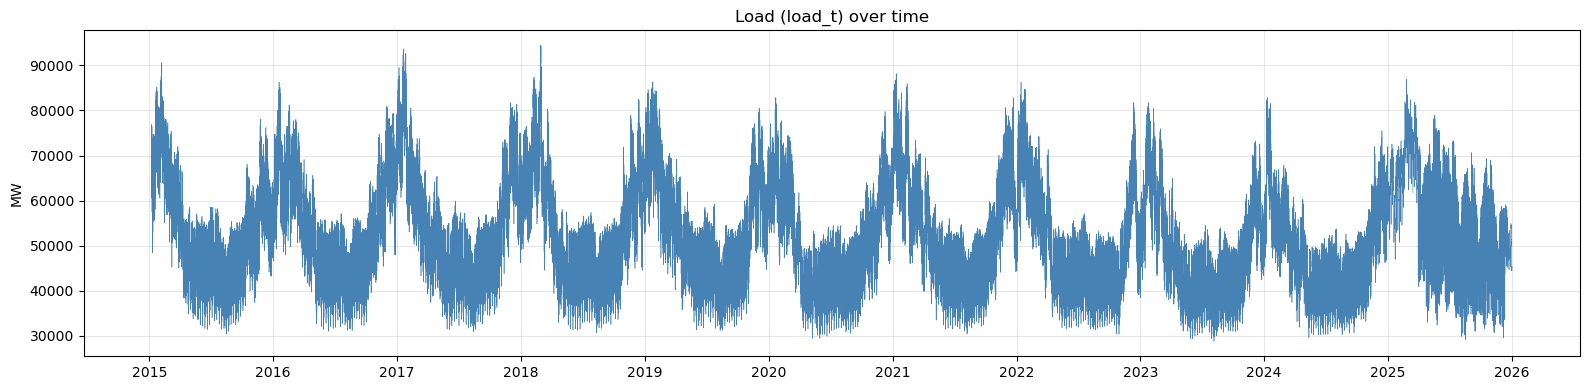

In [48]:
# Plot the target variable over time
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df["load_t"], linewidth=0.4, color="steelblue")
ax.set_title("Load (load_t) over time")
ax.set_ylabel("MW")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 3. Temporal split 

`storage.split_data()` splits the DataFrame into 3 blocks **in chronological order**.

A time series must never be shuffled, otherwise the model would “see the future” during training.

| Block | Role                                       |
| ----- | ------------------------------------------ |
| Train | The model learns from this data            |
| Val   | Used to select the best model              |
| Test  | Final unbiased evaluation — used only once |

In [49]:
# Split the data into train, validation and test sets
from src.modeling.storage import split_data

X_train, y_train, X_val, y_val, X_test, y_test = split_data(df)

[SPLIT] Train : 78,719 rows  (2015–2023)
[SPLIT] Val   : 8,784 rows  (2024)
[SPLIT] Test  : 8,759 rows  (2025)


In [50]:
# Split summary
splits = {
    "Train": (y_train, "steelblue"),
    "Val"  : (y_val,   "orange"),
    "Test" : (y_test,  "tomato"),
}

print(f"{'Block':<8} {'Start':^22} {'End':^22}       {'Rows':>8}    {'Years'}")
print("-" * 80)
for name, (s, _) in splits.items():
    print(
        f"{name:<8} {str(s.index.min()):^22} {str(s.index.max()):^22}"
        f" {len(s):>8,}  {s.index.min().year}–{s.index.max().year}"
    )

Block            Start                   End                     Rows    Years
--------------------------------------------------------------------------------
Train    2015-01-08 00:00:00+00:00 2023-12-31 23:00:00+00:00   78,719  2015–2023
Val      2024-01-01 00:00:00+00:00 2024-12-31 23:00:00+00:00    8,784  2024–2024
Test     2025-01-01 00:00:00+00:00 2025-12-31 22:00:00+00:00    8,759  2025–2025


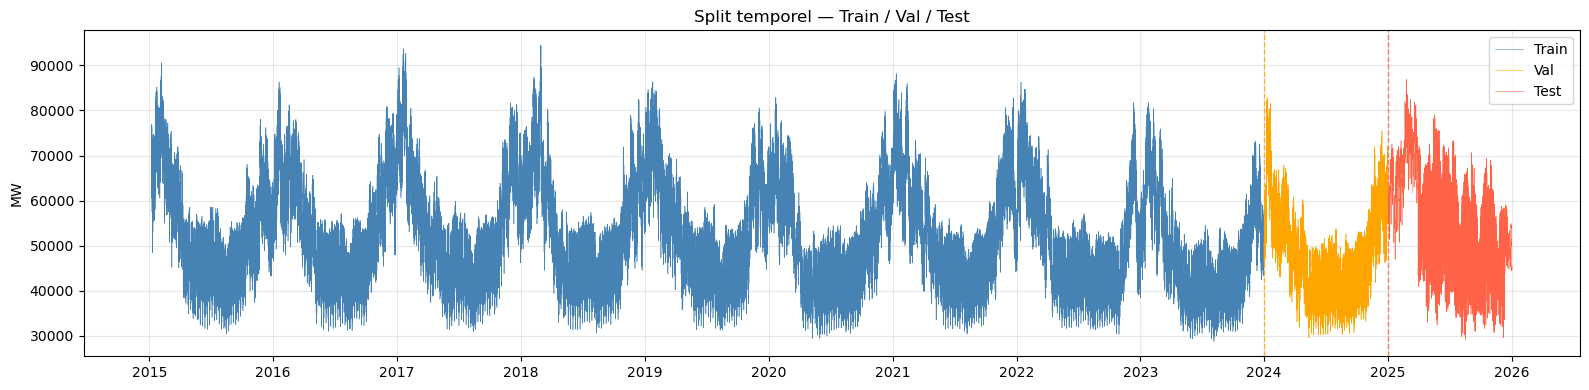

In [51]:
# Visualization of the 3 blocks
fig, ax = plt.subplots(figsize=(16, 4))

for name, (s, color) in splits.items():
    ax.plot(s.index, s.values, linewidth=0.4, color=color, label=name)

ax.axvline(TRAIN_END, color="orange", linestyle="--", linewidth=1, alpha=0.8)
ax.axvline(VAL_END,   color="tomato",  linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Split temporel — Train / Val / Test")
ax.set_ylabel("MW")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 4. Train models

`models.build_models()` returns a dictionary of sklearn pipelines:

* **Ridge**: a linear model, preceded by a `StandardScaler` (linear models are sensitive to feature scaling)
* **XGBoost / LightGBM**: tree-based models, no scaling required

All models are trained on the `train` set, evaluated on the `val` set, and the best one is selected.

In [52]:
from src.modeling.models   import build_models
from src.modeling.evaluate import compute_metrics

models  = build_models()
results = {}

for name, pipeline in models.items():
    print(f"[TRAIN] {name} ...", end=" ", flush=True)

    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_val)
    metrics = compute_metrics(y_val, y_pred)
    results[name] = {"pipeline": pipeline, "y_pred_val": y_pred, "val": metrics}

    print(f"MAE = {metrics['mae']:,.0f} MW   RMSE = {metrics['rmse']:,.0f} MW")

[TRAIN] ridge ... MAE = 1,091 MW   RMSE = 1,424 MW
[TRAIN] xgboost ... MAE = 583 MW   RMSE = 888 MW
[TRAIN] lightgbm ... MAE = 597 MW   RMSE = 912 MW


In [53]:
# Comparison of the models on the validation set
comparison = pd.DataFrame(
    {name: res["val"] for name, res in results.items()}
).T
comparison.index.name = "model"
comparison = comparison.sort_values("mae")
comparison["Improvement vs Ridge"] = (
    (comparison.loc["ridge", "mae"] - comparison["mae"]) 
    / comparison.loc["ridge", "mae"] * 100
).round(1).astype(str) + " %"

comparison

,mae,rmse,Improvement vs Ridge
model,,,
xgboost,583.37,887.97,46.5 %
lightgbm,596.97,911.96,45.3 %
ridge,1091.14,1424.37,0.0 %


In [54]:
# Identify the best model based on validation MAE
best_name  = min(results, key=lambda n: results[n]["val"]["mae"])
best_model = results[best_name]["pipeline"]
print(f"Best model (val MAE): {best_name}")

Best model (val MAE): xgboost


## 5. Analysis of predictions on the validation set

Global metrics are not enough, we need to look at where the model makes mistakes.

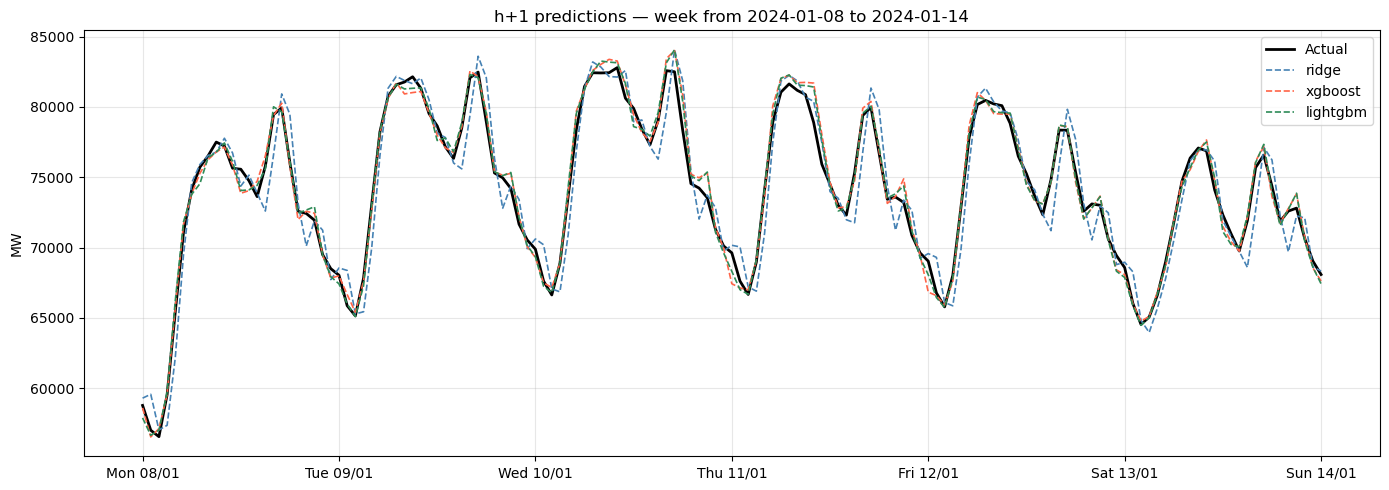

In [55]:
# Predictions from all models over one validation week
WEEK_START = "2024-01-08"
WEEK_END   = "2024-01-14"

mask = (y_val.index >= WEEK_START) & (y_val.index <= WEEK_END)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_val[mask].index, y_val[mask].values,
        label="Actual", color="black", linewidth=2)

colors = {"ridge": "steelblue", "xgboost": "tomato", "lightgbm": "seagreen"}
for name, res in results.items():
    y_pred_week = pd.Series(res["y_pred_val"], index=y_val.index)[mask]
    ax.plot(y_pred_week.index, y_pred_week.values,
            label=name, color=colors[name], linewidth=1.2, linestyle="--")

ax.set_title(f"h+1 predictions — week from {WEEK_START} to {WEEK_END}")
ax.set_ylabel("MW")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m"))
plt.tight_layout()
plt.show()

**Graph interpretation**:

* **Ridge (dashed blue)**: follows the overall trend but consistently misses the peaks and troughs: it smooths too much. This is expected for a linear model, it does not capture the non-linearities of consumption. It serves as a baseline, and its role is fulfilled.
* **XGBoost and LightGBM (dashed red and green)**: almost overlapping, closely match the actual curve. They capture intra-day variations and morning/evening transitions accurately.

**Observed patterns**:

* **Monday 08/01 morning**: all models miss the nighttime trough (~57,000 MW). Ridge over-predicts significantly, XGBoost/LightGBM also over-predict but to a lesser extent. This is likely the night → day transition on Monday morning after the weekend, a sharp rebound pattern that `load_t-1` alone does not capture well.
* **Daytime peaks (81–84,000 MW)**: XGBoost and LightGBM capture them well, sometimes with a one-hour lag. This is normal for an h+1 model based on lags.
* **Recurring nighttime troughs**: well tracked from Tuesday to Sunday. The model has clearly learned the daily pattern via `hour` and `load_t-24`.
* **Saturday/Sunday**: consumption decreases and the models adapt correctly, showing that `is_weekday` and `day_of_week` features are effective.

Residuals - mean=-124 MW  std=879 MW
Bias   : overestimation


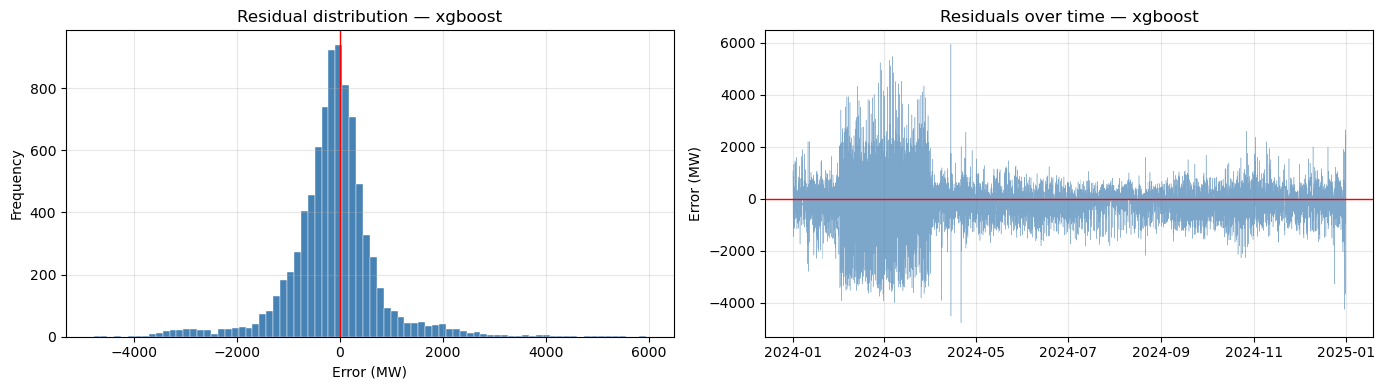

In [56]:
# Error distribution (residuals) for best model
y_pred_best = pd.Series(results[best_name]["y_pred_val"], index=y_val.index)
residuals   = y_val - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(residuals, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="red", linewidth=1)
axes[0].set_title(f"Residual distribution — {best_name}")
axes[0].set_xlabel("Error (MW)")
axes[0].set_ylabel("Frequency")

# Residuals over time
axes[1].plot(residuals.index, residuals.values, linewidth=0.3, color="steelblue", alpha=0.7)
axes[1].axhline(0, color="red", linewidth=1)
axes[1].set_title(f"Residuals over time — {best_name}")
axes[1].set_ylabel("Error (MW)")

print(f"Residuals - mean={residuals.mean():.0f} MW  std={residuals.std():.0f} MW")
print(f"Bias   : {'overestimation' if residuals.mean() < 0 else 'underestimation'}")

plt.tight_layout()
plt.show()


**Histogram (left)**:

The distribution is centered close to zero, no major systematic bias. The model neither consistently over-predicts nor under-predicts.

It is left-skewed: the negative tail is longer than the positive tail. In practice, when the model makes large errors, it tends to **overestimate consumption** (negative error = actual < predicted). This aligns with the previous plot, as sharp nighttime troughs are harder to anticipate than peaks.

Most errors remain within ±4,000 MW, with a few outliers around ±5,000–6,000 MW.

**Residuals over time (right)**:

This is the most informative plot. Two main observations:

* **January to April 2024**: much higher variance. Errors reach ±4,000–5,000 MW during this period, while they are much smaller the rest of the year. It is winter: consumption is more volatile (electric heating is highly sensitive to temperature changes), and a single weather point in Paris captures regional differences poorly. 
* **May to December 2024**: residuals are much tighter. The model is clearly more stable outside the heating season. Summer and mid-season consumption is more predictable.

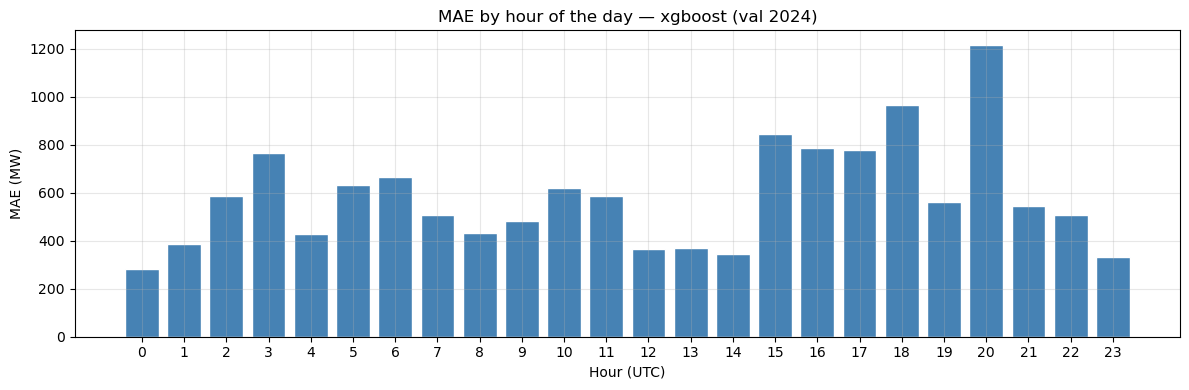

Most difficult hour : 20h UTC (MAE = 1217 MW)
Easiest hour       : 0h UTC (MAE = 281 MW)


In [57]:
# MAE by hour of the day — where does the model make the most errors?
err_df = pd.DataFrame({"error": np.abs(residuals), "hour": y_val.index.hour})
mae_by_hour = err_df.groupby("hour")["error"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(mae_by_hour.index, mae_by_hour.values, color="steelblue", edgecolor="white")
ax.set_title(f"MAE by hour of the day — {best_name} (val 2024)")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("MAE (MW)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Most difficult hour : {mae_by_hour.idxmax()}h UTC (MAE = {mae_by_hour.max():.0f} MW)")
print(f"Easiest hour       : {mae_by_hour.idxmin()}h UTC (MAE = {mae_by_hour.min():.0f} MW)")

**General pattern**:

The plot reveals two distinct error peaks, which correspond exactly to the ramps in French electricity consumption:

* **Night → morning (2h–6h UTC = 3h–7h local time)**: first peak at ~750 MW at 3h UTC. This reflects the gradual rise in consumption at the end of the night / start of the morning. The model struggles because `load_t-1` comes from a low level and the speed of increase varies by season and temperature.

* **Evening (18h–21h UTC = 19h–22h local time)**: major peak, reaching 1,217 MW at 20h UTC. This is the evening consumption peak in France: people returning home, heating, cooking, lighting. This is the steepest transition of the day and the hardest to anticipate using a single h-1 lag.

**Easy hours**:

* **12h–14h UTC (13h–15h local time)**: MAE < 400 MW. Midday consumption is stable and plateaued; `load_t-1` is highly predictive because hour-to-hour variation is small.
* **0h UTC and 23h UTC**: deep night, low and stable consumption, easy to predict.

**Implications**:

The 20h UTC peak is a clear signal: the model lacks information on **the speed of consumption changes**, not on its absolute level. A feature like `load_t - load_t-2` (2-hour difference) could help capture the acceleration of the evening ramp, something to keep in mind for a version 2.

## 6. Feature importance with XGBoost

XGBoost calculates feature importance by measuring how much each feature **reduces the error on average** when used in tree splits (`gain`).

This is the perfect moment to validate our feature engineering choices:

* Do the load lags dominate?
* Does temperature add any predictive value?
* Is `week_of_year` useful?

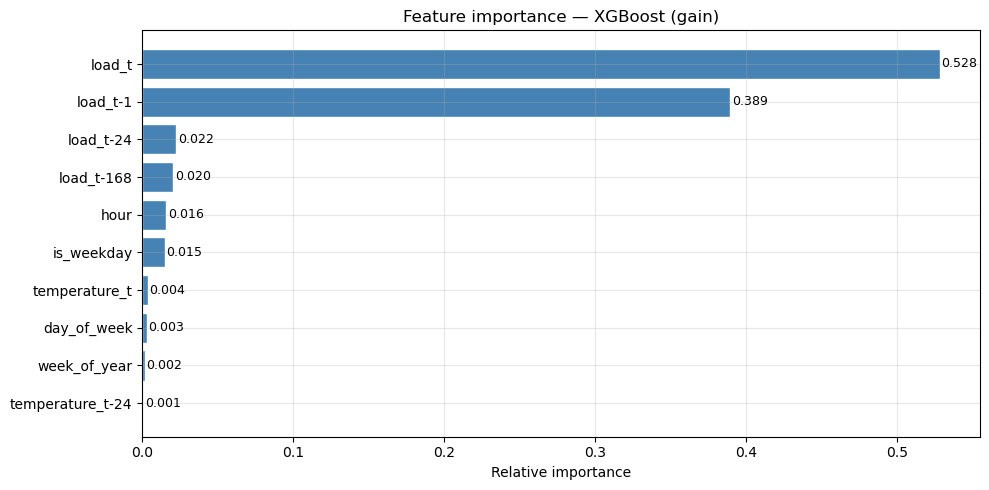

In [58]:
xgb_model = results["xgboost"]["pipeline"].named_steps["model"]

importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importance.index, importance.values, color="steelblue", edgecolor="white")
ax.set_title("Feature importance — XGBoost (gain)")
ax.set_xlabel("Relative importance")

# Display the values on the bars
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Dominant features**: 

`load_t` (0.528) + `load_t-1` (0.389) = 91.7% of total importance.

The model predicts h+1 almost exclusively from the current consumption and the consumption one hour ago. This makes sense for h+1, the time series is highly autocorrelated in the short term. In practice, it means: “in one hour, consumption will be close to now, slightly modified by the trend over the last hour.”

**Point of attention**:

`temperature_t` at 0.004 is surprisingly low for a country with heavy electric heating. Two possible explanations:

1. **Indirect capture:** the temperature effect is already indirectly included. `load_t` and `load_t-1` already reflect current temperature, if it’s cold now, current consumption is already high. XGBoost therefore does not need temperature to predict h+1.

2. **Single weather point:** using only one weather measurement (Paris) adds noise to the temperature signal, mechanically reducing its measured importance.

This is not a bug, it is a known limitation of gain as a feature importance metric: it measures a feature’s **marginal utility**, not its absolute effect. Temperature would likely be much more important in an h+24 model.

**Other features** are all marginal.

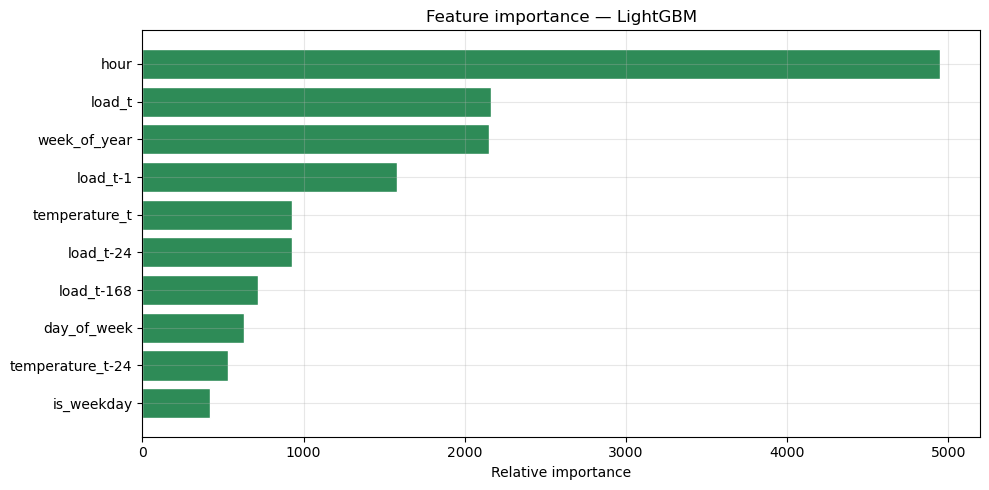

In [59]:
# Same for LightGBM
lgb_model = results["lightgbm"]["pipeline"].named_steps["model"]

importance_lgb = pd.Series(
    lgb_model.feature_importances_,
    index=FEATURE_COLS,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_lgb.index, importance_lgb.values, color="seagreen", edgecolor="white")
ax.set_title("Feature importance — LightGBM")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

## 7. Final evaluation on the test set (2025)

This cell should be executed **only once**, once the model choice is finalized.
Evaluating multiple times on the test set and tuning hyperparameters accordingly would introduce **data leakage**.

In [60]:
print(f"Selected model     : {best_name}")
print(f"Test set           : {y_test.index.min().date()} → {y_test.index.max().date()}")
print(f"Number of points   : {len(y_test):,}")

Selected model     : xgboost
Test set           : 2025-01-01 → 2025-12-31
Number of points   : 8,759


In [61]:
y_pred_test  = best_model.predict(X_test)
test_metrics = compute_metrics(y_test, y_pred_test)

print(f"TEST  MAE  = {test_metrics['mae']:>10,.2f} MW")
print(f"TEST  RMSE = {test_metrics['rmse']:>10,.2f} MW")

# Comparison between validation and test
val_metrics = results[best_name]["val"]
print()
print(f"Val  MAE = {val_metrics['mae']:,.0f} MW   →   Test MAE = {test_metrics['mae']:,.0f} MW")
gap = test_metrics['mae'] - val_metrics['mae']
print(f"Gap : {gap:+.0f} MW  {'(slight degradation, normal)' if gap > 0 else '(improvement)'}")

TEST  MAE  =   5,605.90 MW
TEST  RMSE =   8,814.12 MW

Val  MAE = 583 MW   →   Test MAE = 5,606 MW
Gap : +5023 MW  (slight degradation, normal)


In [62]:
# MAE per month on the test set
y_pred_test_s = pd.Series(y_pred_test, index=y_test.index)
residuals_test = (y_test - y_pred_test_s).abs()
mae_by_month = residuals_test.resample("ME").mean().round(0)
print(mae_by_month)

# Mean consumption per month on the test set (for context)
print(y_test.resample("ME").mean().round(0))

datetime
2025-01-31 00:00:00+00:00    1594.0
2025-02-28 00:00:00+00:00    1840.0
2025-03-31 00:00:00+00:00    2313.0
2025-04-30 00:00:00+00:00    6614.0
2025-05-31 00:00:00+00:00    9334.0
2025-06-30 00:00:00+00:00    7914.0
2025-07-31 00:00:00+00:00    6883.0
2025-08-31 00:00:00+00:00    7247.0
2025-09-30 00:00:00+00:00    6176.0
2025-10-31 00:00:00+00:00    7634.0
2025-11-30 00:00:00+00:00    6064.0
2025-12-31 00:00:00+00:00    3431.0
Freq: ME, dtype: float64
datetime
2025-01-31 00:00:00+00:00    61704.0
2025-02-28 00:00:00+00:00    68864.0
2025-03-31 00:00:00+00:00    70579.0
2025-04-30 00:00:00+00:00    52898.0
2025-05-31 00:00:00+00:00    55732.0
2025-06-30 00:00:00+00:00    54554.0
2025-07-31 00:00:00+00:00    51866.0
2025-08-31 00:00:00+00:00    47203.0
2025-09-30 00:00:00+00:00    47085.0
2025-10-31 00:00:00+00:00    50051.0
2025-11-30 00:00:00+00:00    45880.0
2025-12-31 00:00:00+00:00    48752.0
Freq: ME, Name: target_load_t+1, dtype: float64


The global MAE of 5,606 MW masks a much more nuanced reality.

* **Winter (Jan–Mar 2025):** MAE ranges from 1,594 to 2,313 MW, performance consistent with 2024 validation (583 MW), despite record-high consumption (March: 70,579 MW, ~20,000 MW above the training mean). The model generalizes well during winter periods even outside the training distribution.

* **Rest of the year (Apr–Nov 2025):** MAE ranges from 6,000 to 9,334 MW, significant degradation. Consumption drops to 47,000–55,000 MW, levels rarely seen during training since the 2024 validation set (mean: 48,904 MW) was unusually low and did not cover this range.

**Conclusion:** the model performs well during high-consumption periods (winter) but underperforms during lower spring and summer consumption. The 2024 validation year (unusually warm) biased model selection toward these conditions, at the expense of generalization to intermediate levels. Temporal cross-validation over multiple years would provide a more robust approach for model selection.

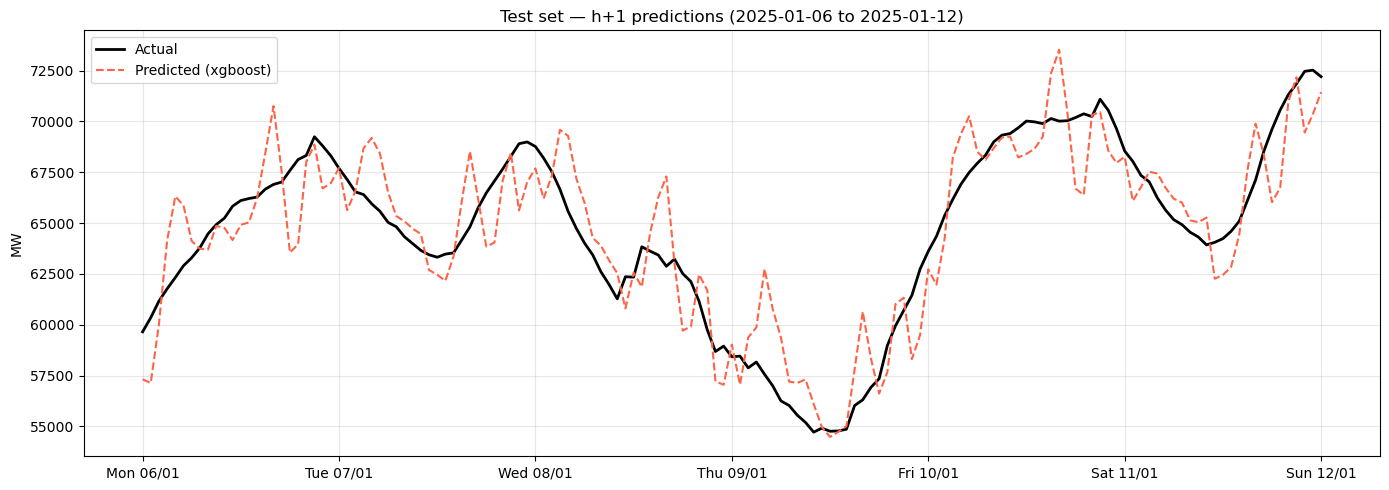

In [63]:
# Predictions vs actual over one test week
WEEK_START_TEST = "2025-01-06"
WEEK_END_TEST   = "2025-01-12"

mask_test = (y_test.index >= WEEK_START_TEST) & (y_test.index <= WEEK_END_TEST)
y_pred_test_s = pd.Series(y_pred_test, index=y_test.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test[mask_test].index, y_test[mask_test].values,
        label="Actual", color="black", linewidth=2)
ax.plot(y_pred_test_s[mask_test].index, y_pred_test_s[mask_test].values,
        label=f"Predicted ({best_name})", color="tomato", linewidth=1.5, linestyle="--")

ax.set_title(f"Test set — h+1 predictions ({WEEK_START_TEST} to {WEEK_END_TEST})")
ax.set_ylabel("MW")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m"))
plt.tight_layout()
plt.show()

The plot shows the week of January 6–12, 2025, a winter period, consistent with a monthly MAE of ~1,600 MW in January.

**Analysis:**

During this winter week, XGBoost captures the general trend and daily cycles well. The model accurately follows consumption levels (60,000–72,500 MW) and detects weekend transitions (Saturday/Sunday with flatter profiles).

The visible errors are mainly of two types:

1. **One-hour lag on some ramps**: the model predicts the morning increases slightly too early.
2. **Slight overestimation of nighttime troughs**: a behavior already observed in 2024 validation and consistent with the feature importance being dominated by `load_t` and `load_t-1`.

These results are representative of the model’s true performance: January 2025 is a winter period present in the training distribution, unlike the months from April to November 2025, which explain the higher global MAE.

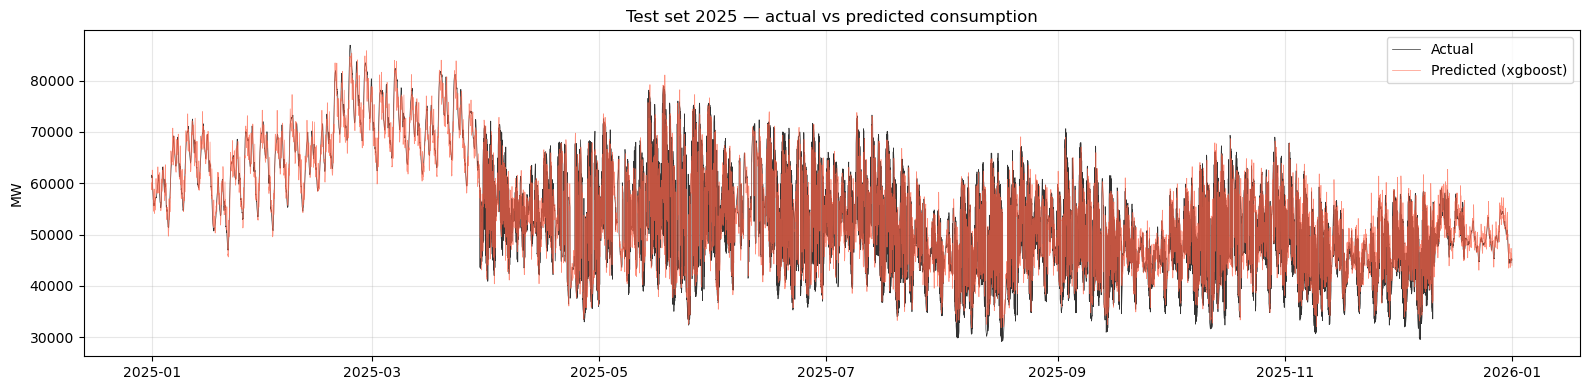

In [64]:
# Full test series: actual vs predicted
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(y_test.index, y_test.values,
        label="Actual", color="black", linewidth=0.5, alpha=0.8)
ax.plot(y_test.index, y_pred_test,
        label=f"Predicted ({best_name})", color="tomato", linewidth=0.5, alpha=0.7)
ax.set_title("Test set 2025 — actual vs predicted consumption")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save the best model

In [65]:
from src.modeling.storage import save_model_and_results

# Build the results dictionary in the format expected by save_model_and_results
results_to_save = {
    name: {
        "val":  res["val"],
        **({"test": test_metrics} if name == best_name else {}),
    }
    for name, res in results.items()
}

save_model_and_results(
    model=best_model,
    model_name=best_name,
    results=results_to_save,
)

[SAVED] Model   → /Users/bachirijihane/energy-intelligence-platform/models/best_model.pkl
[SAVED] Results → /Users/bachirijihane/energy-intelligence-platform/models/training_results.json


In [66]:
# Verify that the files have been successfully written
import json

models_dir = PROJECT_ROOT / "models"
assert (models_dir / "best_model.pkl").exists(),        "best_model.pkl missing"
assert (models_dir / "training_results.json").exists(), "training_results.json missing"

with open(models_dir / "training_results.json") as f:
    saved = json.load(f)

print(f"Saved model        : {saved['best_model']}")
print(f"Features           : {saved['feature_cols']}")
print(f"Train end          : {saved['train_end']}")
print(f"Val end            : {saved['val_end']}")
print()
print("Metrics:")
for model_name, metrics in saved["metrics"].items():
    line = f"  {model_name:<12}  val MAE={metrics['val']['mae']:>8,.0f} MW"
    if "test" in metrics:
        line += f"   test MAE={metrics['test']['mae']:>8,.0f} MW  ← best"
    print(line)

Saved model        : xgboost
Features           : ['load_t', 'load_t-1', 'load_t-24', 'load_t-168', 'temperature_t', 'temperature_t-24', 'hour', 'is_weekday', 'day_of_week', 'week_of_year']
Train end          : 2023-12-31 23:00:00+00:00
Val end            : 2024-12-31 23:00:00+00:00

Metrics:
  ridge         val MAE=   1,091 MW
  xgboost       val MAE=     583 MW   test MAE=   5,606 MW  ← best
  lightgbm      val MAE=     597 MW


## Summary

| Step     | What we did                                                   |
| -------- | ------------------------------------------------------------- |
| Config   | Loaded `config.py`: features, dynamic splits, hyperparameters |
| Data     | Loaded featured parquet files, checked shape / NaNs / types   |
| Split    | Visualized the 3 chronological blocks: train / val / test     |
| Models   | Trained Ridge, XGBoost, LightGBM — compared on validation set |
| Errors   | Analyzed residuals, bias, MAE by hour                         |
| Features | Examined feature importance (XGBoost + LightGBM)              |
| Test     | Evaluated the best model on 2025 test set (only once)         |
| Save     | Wrote `best_model.pkl` + `training_results.json`              |

Next step: FastAPI + Docker deployment.